In [1]:
import sys
sys.path.append('../module')

import os, math
from collections import defaultdict, namedtuple, deque
import dataclasses
from dataclasses import dataclass
import itertools
import sqlite3
import logging
import logging.handlers
import pickle
import datetime
import multiprocessing as mp
import gc

from PIL import Image, ImageDraw
from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split
from scipy.fft import rfft, rfftfreq, irfft
import matplotlib.pyplot as plt
import scipy
import numpy as np
import cupy as cp
import pandas as pd

from utils import *
from hdc import *
from constants import *

In [2]:
LOG = Logging()

config_var = 'SQLITE3_SEQ_GRID_0_2_4096'
config = Config(config_var, config_fname=os.path.join('..', 'config.txt'))
RNG = np.random.default_rng()
mp_ctx = mp.get_context('spawn') # req-d for CUPY to work, 'fork' method leads to failures in bootstrap somewhere around CUDA

if cp.cuda.is_available():
    xp = cp.get_array_module(cp.empty(1))
    xp_array_from_gpu = lambda a: a.get() if isinstance(a, cp.ndarray) else a
    xp_array_to_gpu = lambda a: cp.asarray(a) if isinstance(a, np.ndarray) else a
    xp_array_to_gpu_copy = lambda a: cp.asarray(a) if isinstance(a, np.ndarray) else a
else:
    xp = cp.get_array_module(np.empty(1))
    xp_array_from_gpu = lambda a: a
    xp_array_to_gpu = lambda a: a
    xp_array_to_gpu_copy = lambda a: a.copy()

print(f'xp = {xp.__name__}')

hdc = Hdc(10_000, xp)

xp = numpy


In [3]:
%run ../sequencing_sp2.ipynb

In [4]:
train_db_con = sqlite3.connect(DBUtils.get_full_db_file_name(config, config.train_db_file_name))
df_train_images = pd.read_sql_query('SELECT * FROM images', con=train_db_con, index_col='image_id')

In [5]:
image_id = RNG.choice(df_train_images.index)

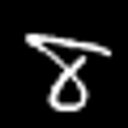

In [6]:
df_image = df_train_images.loc[image_id]
Image.open(io.BytesIO(df_image['png']))

In [13]:
fetch_si_xy = lambda si: (si.x, si.y)
get_sequence = lambda sequences: np.array(list(itertools.chain.from_iterable(sequences)))
get_sequences_reading = lambda sequences, seq_reading_code: list(map(lambda r: sequences[r[0]] if r[1] == 0 else list(reversed(sequences[r[0]])), seq_reading_code))
get_xy_sequence = lambda sequence, si_ind_dict: np.array(list(map(lambda si_ind: fetch_si_xy(si_ind_dict[si_ind]), sequence)))
get_raw_image = lambda image_id: Image.open(io.BytesIO((df_train_images if image_id < 100_000_000 else df_test_images).loc[image_id]['png']))
get_cs_point_activations_vec = lambda seq_bv: ((CS_POINTS @ seq_bv) > 0).astype('f')

In [14]:
def calc_seq_ipxy(sequences, si_ind_dict):
    res = []  # transcript of sequences with full interpolation by xy 
        
    for sequence in sequences:
        xy_sequence = get_xy_sequence(sequence, si_ind_dict)
        xy_sequence_fwd = np.roll(xy_sequence, -1, axis=0)
        vec_sequence = xy_sequence_fwd - xy_sequence
        vec_sequence[-1,:] = 0 # get rid of reciprocal vector which connects tail to tip
        vec_len_sequence = np.linalg.norm(vec_sequence, axis=1)
        vec_len_sequence_nozero = np.where(vec_len_sequence != 0, vec_len_sequence, 1e-6) # prevent 0 len vectors
        norm_vec_sequence = (vec_sequence.T / vec_len_sequence_nozero).T
        vec_len_sequence = np.round(vec_len_sequence, decimals=0).astype(int)
        
        assert len(sequence) == vec_sequence.shape[0]
        assert len(sequence) == vec_len_sequence.shape[0]
        assert len(sequence) == norm_vec_sequence.shape[0]
        
        for pt, pt_to, norm_vec, vec_len in zip(xy_sequence, xy_sequence_fwd, norm_vec_sequence, vec_len_sequence):
            if vec_len <= 0:
                continue

            pts = pt + (np.arange(vec_len) * norm_vec[np.newaxis,:].T).T # path interpolation
            pts = np.round(pts, decimals=0).astype(int)
            res.append(pts)
            res.append(pt_to)

    assert res
    res = np.vstack(res)
    return res

In [25]:
HP_COMBI_SPACE_SIZE = 32
HP_SIGNAL_LEARN_OBSERVATIONS_COUNT_TRHES = 1
HP_SIGNAL_PC_BINARIZE_THRES = 0.75

In [89]:
def calc_seq_bv(seq_xy):
    seq_xy = xp_array_to_gpu(seq_xy)
    seq_xy = seq_xy * (HP_COMBI_SPACE_SIZE / config.sample_size)
    # Leave only points which fit into square defined by HP_COMBI_CLUSTERS_SPACE_SIZE,
    # use filtering instead of clipping (np.clip) because clipping tends to introduce false point clustering at the bounadries
    seq_xy = xp.round(seq_xy, decimals=0)
    ii = xp.all(((seq_xy >= 0) & (seq_xy < HP_COMBI_SPACE_SIZE)), axis=1) 
    seq_xy = seq_xy[ii]
    ind_seq = (seq_xy @ xp.array([1, HP_COMBI_SPACE_SIZE])).astype(int)
    bitmap_vec = xp.zeros((HP_COMBI_SPACE_SIZE, HP_COMBI_SPACE_SIZE), dtype='f').ravel()
    bitmap_vec[ind_seq] = 1
    return bitmap_vec

In [90]:
Matchee = namedtuple('Matchee', 
                     ['image_id',
                      'value',
                      'seq_reading_codes', 
                      'sequences', 
                      'si_ind_dict'])

def create_matchee(df_image, seq_reading_code=None):
    si_ind_dict = pickle.loads(df_image.inner_si_ind_dict)
    sequences = pickle.loads(df_image.inner_sequences)
    seq_reading_codes = [list(zip(range(len(sequences)), [0] * len(sequences)))]

    return Matchee(image_id=int(df_image.Index), 
                   value=df_image.value, 
                   seq_reading_codes=seq_reading_codes, 
                   sequences=sequences, 
                   si_ind_dict=si_ind_dict)

In [91]:
def thin_out_sequences(sequences, p):
    result = []
    
    for seq in sequences:
        to_drop_inds = RNG.random(len(seq)) < p
        new_seq = []

        for si_ind, is_dropped in zip(seq, to_drop_inds):
            if is_dropped:
                if new_seq:
                    result.append(new_seq)

                new_seq = []
                continue
            
            new_seq.append(si_ind)

        if new_seq:
            result.append(new_seq)

    return result

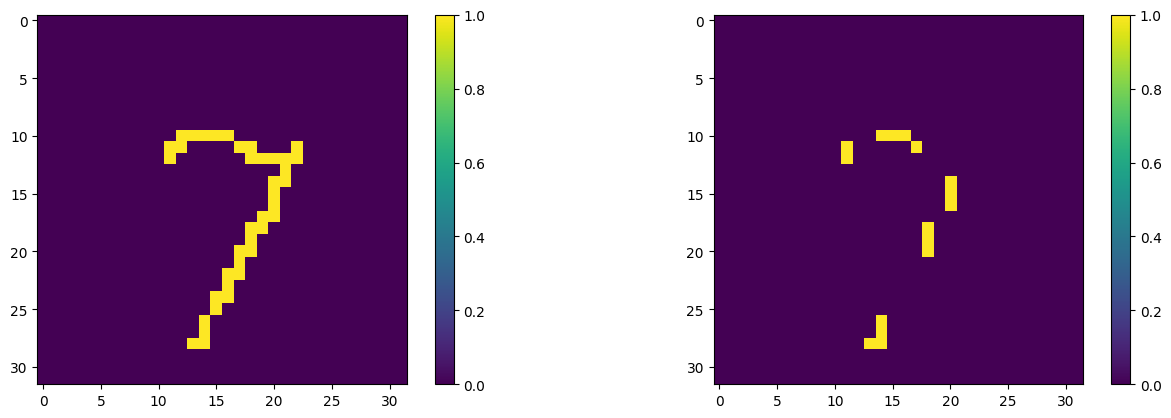

In [92]:
image_id = 773
image = next(df_train_images.loc[[image_id]].itertuples())
matchee = create_matchee(image)
seq_reading = get_sequences_reading(matchee.sequences, matchee.seq_reading_codes[0])
seq_ipxy = calc_seq_ipxy(seq_reading, matchee.si_ind_dict)
seq_bv = calc_seq_bv(seq_ipxy)
# seq_bv = (-0.5 + seq_bv)

# 1)
# seq_bv2 = calc_seq_bv(seq_ipxy + np.array([10, -30]))

# 2)
# seq_bv2 = np.roll(seq_bv.reshape(32, -1), 8, axis=1)
# seq_bv2 = np.roll(seq_bv2.reshape(32, -1), -8, axis=0)
# seq_bv2 = seq_bv2.ravel()

# 3)
# move_to_ooc_transf = np.array([
#     [1, 0, -config.sample_size / 2],
#     [0, 1, -config.sample_size / 2],
#     [0, 0, 1]])
# theta = np.deg2rad(0)
# cos_theta = math.cos(theta)
# sin_theta = math.sin(theta)
# rotation_transf = np.array([
#     [cos_theta, -sin_theta, 0],
#     [sin_theta, cos_theta, 0],
#     [0, 0, 1]
# ])
# move_to_target_loc_transf = np.array([
#     [1, 0, config.sample_size / 2],
#     [0, 1, config.sample_size / 2],
#     [0, 0, 1]])
# transf = move_to_target_loc_transf @ rotation_transf @ move_to_ooc_transf

# transf = np.array([
#     [1.5, 0, -40],
#     [0, 1.5, -50],
#     [0, 0, 1]])

# seq_ipxy2 = np.hstack([seq_ipxy, np.ones(seq_ipxy.shape[0])[:,np.newaxis]]) # make homogeneous coords
# seq_ipxy2 = xp_array_to_gpu(transf @ seq_ipxy2.T).T[:,:2]
# seq_bv2 = calc_seq_bv(seq_ipxy2)

# 4)
seq_reading2 = thin_out_sequences(seq_reading, 0.5)
seq_ipxy2 = calc_seq_ipxy(seq_reading2, matchee.si_ind_dict)
seq_bv2 = calc_seq_bv(seq_ipxy2)

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(16)
im = ax1.imshow(seq_bv.reshape(32, -1))
fig.colorbar(im, ax=ax1)
im = ax2.imshow(seq_bv2.reshape(32, -1))
fig.colorbar(im, ax=ax2);

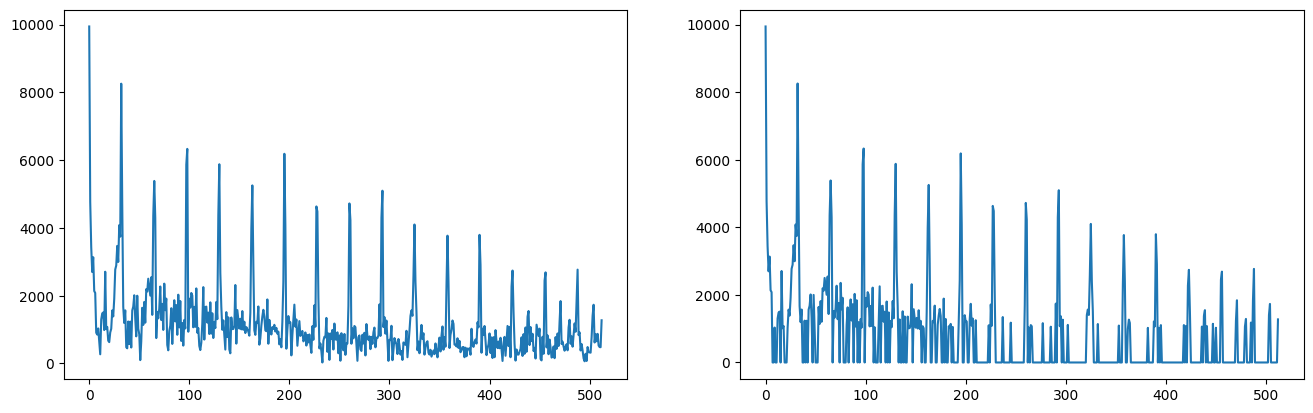

In [88]:
yf = rfft(seq_bv)
# yf_clip = np.where(np.abs(yf) > 10, yf, 0)
yf_clip = np.where(np.abs(yf) > np.max(np.abs(yf)) * 0.1, yf, 0)
xf = rfftfreq(seq_bv.shape[0], 1 / seq_bv.shape[0])

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(16)
ax1.plot(xf, np.abs(yf))
ax2.plot(xf, np.abs(yf_clip));

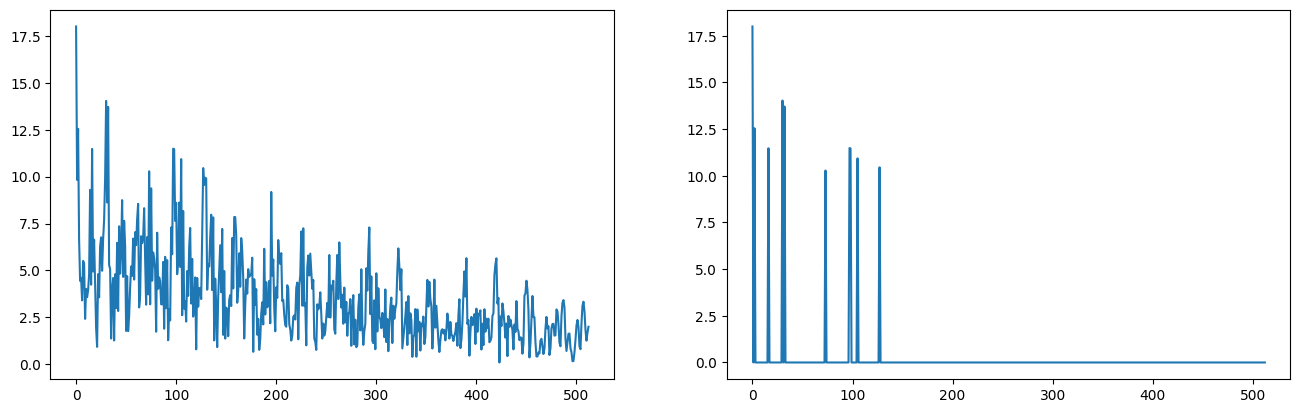

In [48]:
yf2 = rfft(seq_bv2)
yf2_clip = np.where(np.abs(yf2) > 10, yf2, 0)
xf = rfftfreq(seq_bv.shape[0], 1 / seq_bv.shape[0])

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(16)
ax1.plot(xf, np.abs(yf2))
ax2.plot(xf, np.abs(yf2_clip))
plt.show()

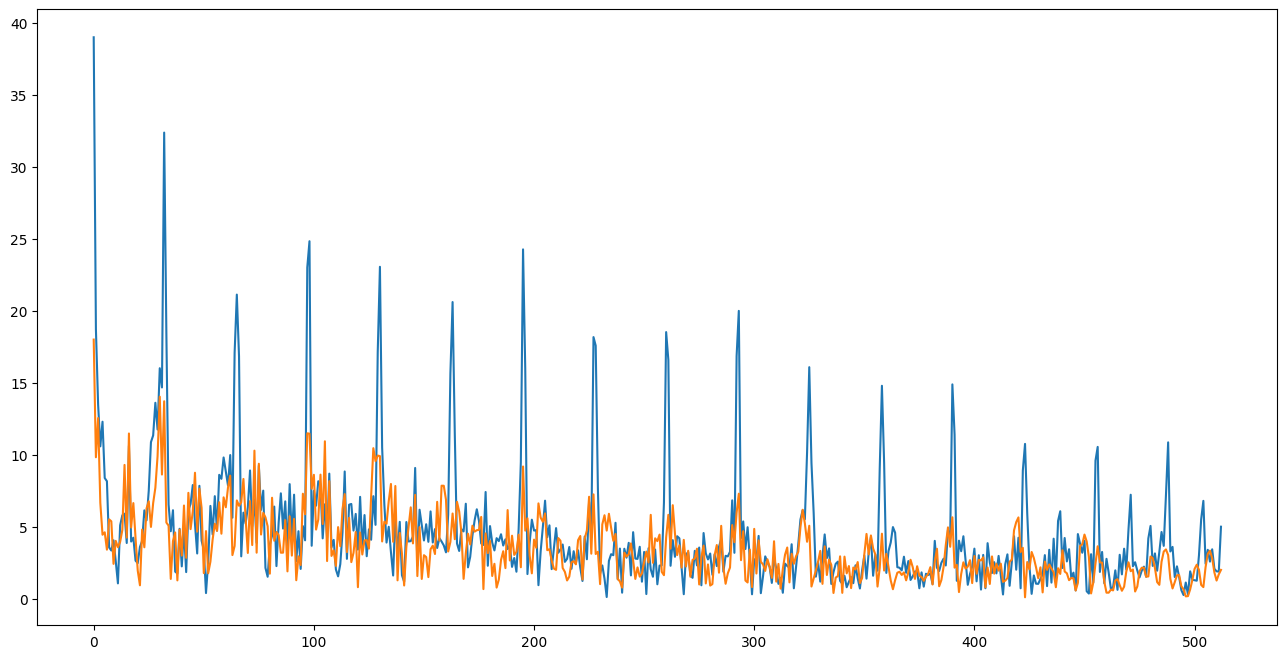

In [49]:
plt.figure(figsize=(16, 8))
plt.plot(xf, np.abs(yf))
plt.plot(xf, np.abs(yf2))
plt.show()

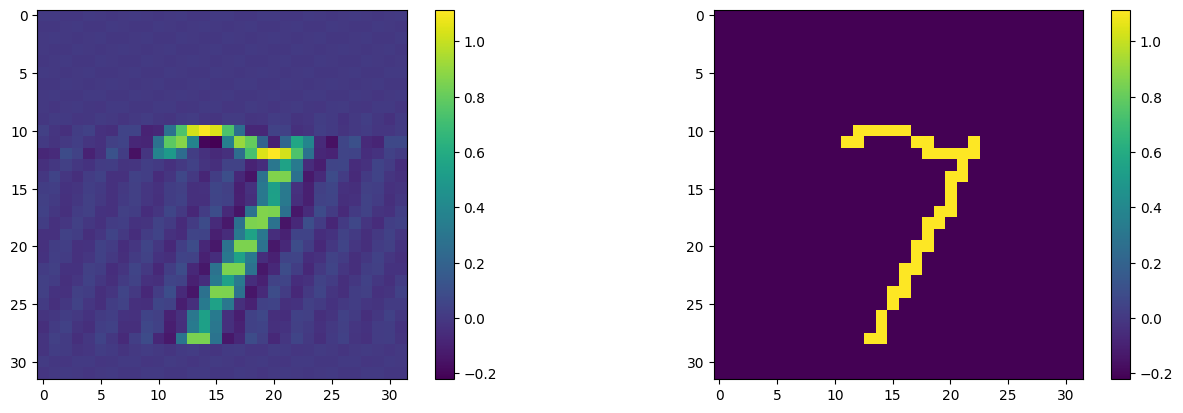

In [78]:
# yf_clip = np.where(np.abs(yf) > np.max(np.abs(yf)) * 0.2, yf, 0)
yf_clip = yf.copy()
yf_clip[270:] = 0
xf_hat = irfft(yf_clip)

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(16)
im = ax1.imshow(xf_hat.reshape(32, -1))
fig.colorbar(im, ax=ax1)
xf_hat_clipped = np.where(xf_hat > 0.5, 1, 0)
ax2.imshow(xf_hat_clipped.reshape(32, -1));
fig.colorbar(im, ax=ax2);

In [51]:
list(map(lambda i: (i.Index, i.value), df_train_images.loc[RNG.choice(df_train_images.index, 10)].itertuples()))

[(33046, '5'),
 (40127, '5'),
 (31209, '1'),
 (24305, '9'),
 (22962, '6'),
 (6122, '1'),
 (31972, '8'),
 (13804, '2'),
 (30433, '7'),
 (57608, '3')]

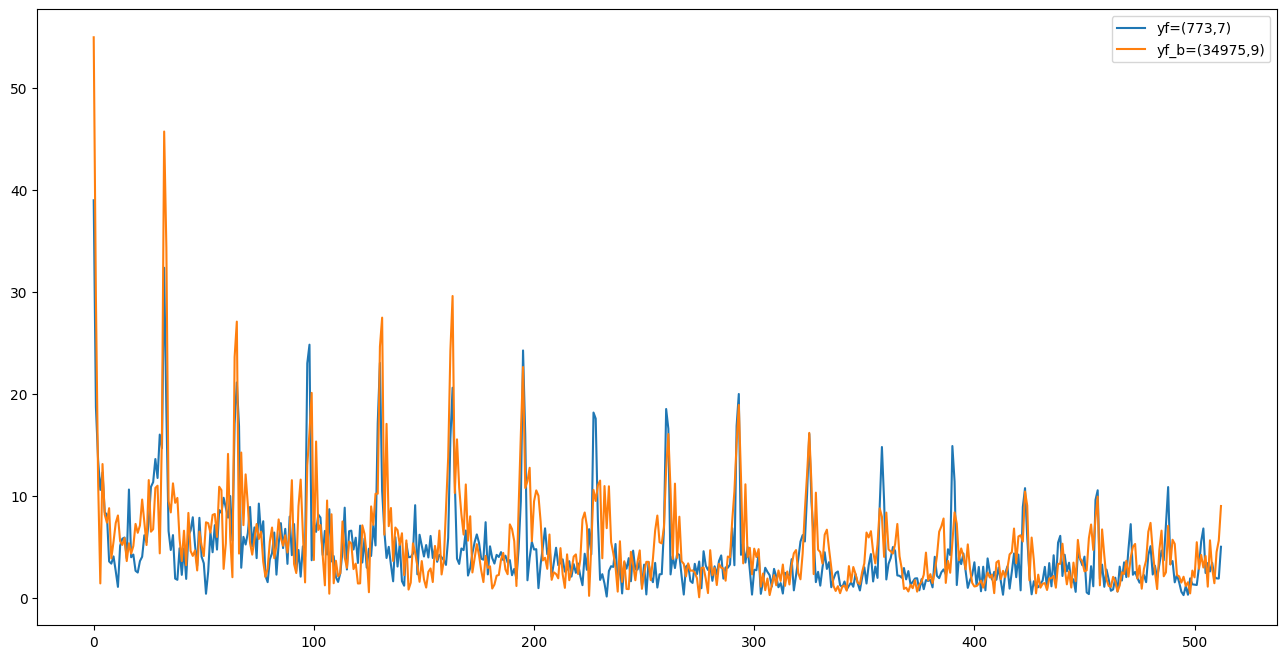

In [52]:
image_id_b = 34975
image_b = next(df_train_images.loc[[image_id_b]].itertuples())
matchee_b = create_matchee(image_b)
seq_reading_b = get_sequences_reading(matchee_b.sequences, matchee_b.seq_reading_codes[0])
seq_ipxy_b = calc_seq_ipxy(seq_reading_b, matchee_b.si_ind_dict)
seq_bv_b = calc_seq_bv(seq_ipxy_b)
yf_b = rfft(seq_bv_b)

plt.figure(figsize=(16, 8))
plt.plot(xf, np.abs(yf), label=f'yf=({image.Index},{image.value})')
plt.plot(xf, np.abs(yf_b), label=f'yf_b=({image_b.Index},{image_b.value})')
plt.legend()
plt.show()

# fig, (ax1, ax2) = plt.subplots(1, 2)
# fig.set_figwidth(16)
# ax1.plot(xf, np.abs(yf_b))
# ax2.plot(xf, np.abs(yf))
# plt.show()

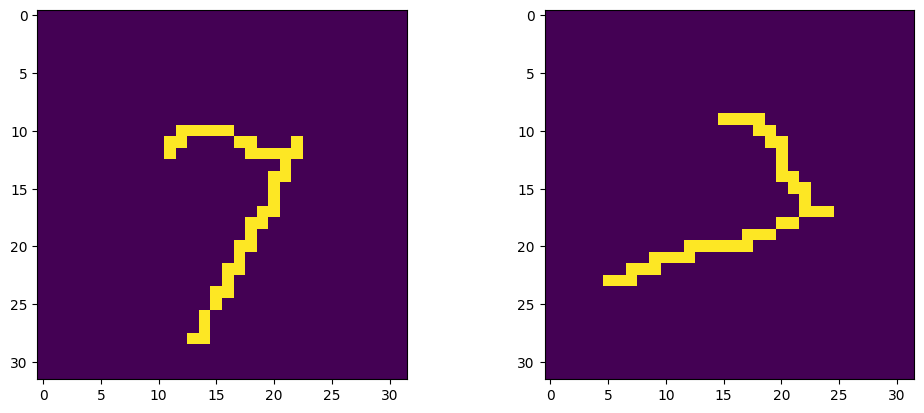

In [62]:
image_id = 773
image = next(df_train_images.loc[[image_id]].itertuples())
matchee = create_matchee(image)
seq_reading = get_sequences_reading(matchee.sequences, matchee.seq_reading_codes[0])
seq_ipxy = calc_seq_ipxy(seq_reading, matchee.si_ind_dict)
seq_bv = calc_seq_bv(seq_ipxy)

move_to_ooc_transf = np.array([
    [1, 0, -config.sample_size / 2],
    [0, 1, -config.sample_size / 2],
    [0, 0, 1]])
theta = np.deg2rad(45)
cos_theta = math.cos(theta)
sin_theta = math.sin(theta)
rotation_transf = np.array([
    [cos_theta, -sin_theta, 0],
    [sin_theta, cos_theta, 0],
    [0, 0, 1]
])
move_to_target_loc_transf = np.array([
    [1, 0, config.sample_size / 2],
    [0, 1, config.sample_size / 2],
    [0, 0, 1]])
transf = move_to_target_loc_transf @ rotation_transf @ move_to_ooc_transf

# transf = np.array([
#     [1, 0, 10],
#     [0, 1, 0],
#     [0, 0, 1]])

seq_ipxy2 = np.hstack([seq_ipxy, np.ones(seq_ipxy.shape[0])[:,np.newaxis]]) # make homogeneous coords
seq_ipxy2 = (transf @ seq_ipxy2.T).T[:,:2]
# seq_ipxy2 = seq_ipxy2 - seq_ipxy2[0] + seq_ipxy[0]
seq_bv2 = calc_seq_bv(seq_ipxy2)

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(12)
ax1.imshow(seq_bv.reshape(32, -1))
ax2.imshow(seq_bv2.reshape(32, -1))
plt.show()

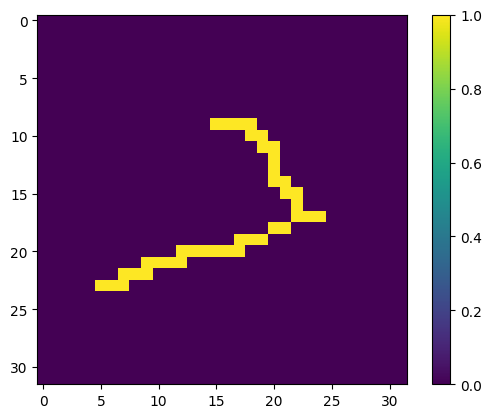

In [63]:
# convolution in Freq domain corresponds to multiplication in time domain and vice versa
f1 = rfft(seq_bv)
f2 = rfft(seq_bv2)
m = f2 / f1

seq_bv2 = irfft(f1 * m)
plt.imshow(seq_bv2.reshape(32, -1))
plt.colorbar()
plt.show()

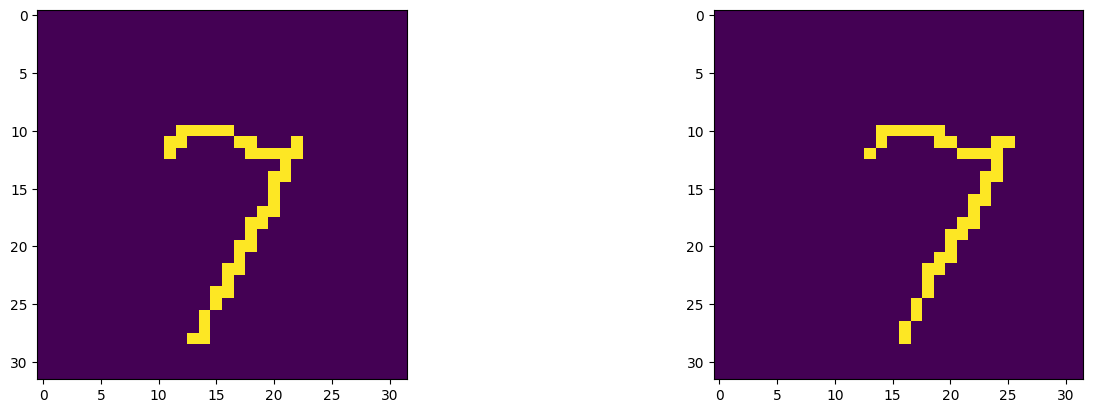

In [56]:
image_id_b = 773
image_b = next(df_train_images.loc[[image_id_b]].itertuples())
matchee_b = create_matchee(image_b)
seq_reading_b = get_sequences_reading(matchee_b.sequences, matchee_b.seq_reading_codes[0])
seq_ipxy_b = calc_seq_ipxy(seq_reading_b, matchee_b.si_ind_dict)
seq_bv_b = calc_seq_bv(seq_ipxy_b)

seq_bv_b2 = irfft(rfft(seq_bv_b) * m)
seq_bv_b2 = np.where(seq_bv_b2 > 0.5, 1, 0)

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(16)
ax1.imshow(seq_bv_b.reshape(32, -1))
ax2.imshow(seq_bv_b2.reshape(32, -1))
plt.show()

In [ ]:
https://us04web.zoom.us/j/5116500408?pwd=UHZ0RWR1RVpzbVhqb1RJSm43bE9jdz09